# Weekly Project 02 - Image Features

## Robot Tracking

It is recommended that you finish the exercises from Monday, before starting the project.

For this project you are given a video of some mobile robots (Robots.mp4). The task is now to track only the robots that are moving. Try to use both sparse and dense optical flow and compare the results.

For sparse optical flow, draw the tracked keypoints onto each frame and try to show the frames fast enough, such that it looks like a video.

For dense optical flow, represent the movement in any way you see fitting. For example by making a new image with the colors of each pixel representing the movement.



In [10]:
import cv2
import numpy as np
from matplotlib import pyplot as plt

In [11]:
cap = cv2.VideoCapture("Robots.mp4")

frames = []

while True:
    ret, frame = cap.read()

    if not ret:
        break
    frame_gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
    frames.append(frame_gray.copy())

cap.release()

print(f"Stored {len(frames)} frames")

Stored 482 frames


(np.float64(-0.5), np.float64(1919.5), np.float64(1079.5), np.float64(-0.5))

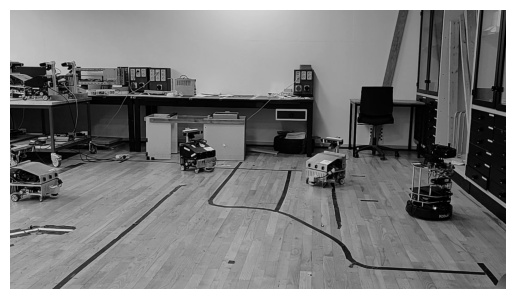

In [12]:
plt.imshow(cv2.cvtColor(frames[0], cv2.COLOR_BGR2RGB))
plt.axis("off")

In [ ]:
features = []
frames_opt_flow = []
trail = np.zeros_like(frames)
# Detetar pontos de interesse no primeiro frame
feat = cv2.goodFeaturesToTrack(frames[0], maxCorners=100, qualityLevel=0.2, minDistance=7)
features.append(feat)

# Processar todos os frames sequencialmente
for i in range(1, len(frames)):
    feat, status, error = cv2.calcOpticalFlowPyrLK(frames[i-1], frames[i], features[i-1], None)
    features.append(feat)
    
    # Converte o frame cinzento para BGR para permitir cores (verde)
    img_draw = cv2.cvtColor(frames[i].copy(), cv2.COLOR_GRAY2BGR)
    
    for j in range(len(features[i])):
        f10 = int(features[i-1][j][0][0])
        f11 = int(features[i-1][j][0][1])
        f20 = int(features[i][j][0][0])
        f21 = int(features[i][j][0][1])
        
        cv2.line(img_draw, (f10, f11), (f20, f21), (0, 255, 0), 2)
        cv2.circle(img_draw, (f10, f11), 5, (0, 255, 0), -1)
        
    frames_opt_flow.append(img_draw)

# Reproduzir os frames acumulados como vídeo
for frame in frames_opt_flow:
    cv2.imshow("Optical Flow Video", frame)
    # 30ms de espera equivale a ~33 fps. Pressiona 'q' para fechar.
    if cv2.waitKey(30) & 0xFF == ord('q'):
        break

cv2.destroyAllWindows()


In [ ]:
frames3 = []

for i in range(1, len(frames)):
    flow = cv2.calcOpticalFlowFarneback(frames[i-1], frames[i], None, 0.5, 3, 15, 3, 5, 1.1, 0)
    
    mag, ang = cv2.cartToPolar(flow[:,:,0], flow[:,:,1])
    sampling = 20
    sam_mag, sam_ang = mag[::sampling, ::sampling], ang[::sampling, ::sampling]
    
    frame_color = cv2.cvtColor(frames[i].copy(), cv2.COLOR_GRAY2BGR)
    
    # Obter a altura (h) e largura (w) reais para o grid
    h, w = mag.shape[0], mag.shape[1]
    
    # Substituído '1000' por 'h' na altura e 'w' na largura
    start = np.mgrid[0:h:sampling, 0:w:sampling]
    
    end_point = (
        np.clip(np.squeeze(start[0, ...]) + sam_mag * np.cos(sam_ang), 0, h),
        np.clip(np.squeeze(start[1, ...]) - sam_mag * np.sin(sam_ang), 0, w)
    )
    
    for I in range(sam_mag.shape[0]):
        for j in range(sam_mag.shape[1]):
            cv2.line(frame_color, (j * sampling, I * sampling), (int(end_point[1][I, j]), int(end_point[0][I, j])), (0, 255, 0), 2)
            cv2.circle(frame_color, (int(end_point[1][I, j]), int(end_point[0][I, j])), 3, (0, 0, 255), -1)
            
    frames3.append(frame_color)

# Reprodução
for frame in frames3:
    cv2.imshow("Optical Flow Video", frame)
    if cv2.waitKey(30) & 0xFF == ord('q'):
        break

cv2.destroyAllWindows()